# 1. Librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [440]:
sns.set()

# 2. Import et exploration des données

## 2.1 Disponibilité alimentaire - FAO (fichier DisponibiliteAlimentaire_2017.csv)

In [4]:
df_disponibilite_alimentaire = pd.read_csv('DisponibiliteAlimentaire_2017.csv', sep=',')

In [5]:
df_disponibilite_alimentaire.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [6]:
print(f"Le fichier DisponibiliteAlimentaire_2017 comporte {df_disponibilite_alimentaire.shape[0]} observations et {df_disponibilite_alimentaire.shape[1]} colonnes. Les colonnes en question sont:")
for i in df_disponibilite_alimentaire.columns:
    print("- " + i)

Le fichier DisponibiliteAlimentaire_2017 comporte 176600 observations et 14 colonnes. Les colonnes en question sont:
- Code Domaine
- Domaine
- Code zone
- Zone
- Code Élément
- Élément
- Code Produit
- Produit
- Code année
- Année
- Unité
- Valeur
- Symbole
- Description du Symbole


Intéressons nous à présent au contenu des colonnes.

In [8]:
code_domaine_values = df_disponibilite_alimentaire["Code Domaine"].unique().item()
print(f"La colonne \"Code Domaine\" ne contient qu'une valeur, {code_domaine_values}, nous n'en avons pas besoin pour notre analyse.")

La colonne "Code Domaine" ne contient qu'une valeur, FBS, nous n'en avons pas besoin pour notre analyse.


In [9]:
domaine_values = df_disponibilite_alimentaire["Domaine"].unique().item()
print(f"La colonne \"Domaine\" ne contient qu'une valeur, {domaine_values}, nous n'en avons pas besoin pour notre analyse.")

La colonne "Domaine" ne contient qu'une valeur, Nouveaux Bilans Alimentaire, nous n'en avons pas besoin pour notre analyse.


In [10]:
annee_values = df_disponibilite_alimentaire["Année"].unique().item()
print(f"Ce fichier ne concerne qu'une année, {annee_values}. Nous n'en avons pas besoin de cette colonne pour la suite de notre analyse.")

Ce fichier ne concerne qu'une année, 2017. Nous n'en avons pas besoin de cette colonne pour la suite de notre analyse.


In [11]:
code_annee_values = df_disponibilite_alimentaire["Code année"].unique().item()
print(f"La colonne \"Code année\" ne contient qu'une valeur, {code_annee_values}, et est redondante. Nous n'en avons pas besoin pour notre analyse.")

La colonne "Code année" ne contient qu'une valeur, 2017, et est redondante. Nous n'en avons pas besoin pour notre analyse.


In [12]:
symbole_values = df_disponibilite_alimentaire["Symbole"].unique()
print(f"La colonne \"Symbole\" contient les valeurs {' et '.join(symbole_values)}.")

La colonne "Symbole" contient les valeurs S et Fc.


In [13]:
description_symbole_values = df_disponibilite_alimentaire["Description du Symbole"].unique()
print(f"La colonne \"Description du Symbole\" contient les valeurs {' et '.join(description_symbole_values)}.")

La colonne "Description du Symbole" contient les valeurs Données standardisées et Donnée calculée.


In [14]:
df_disponibilite_alimentaire.head(20)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.00,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.00,S,Données standardisées
5,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5521,Aliments pour animaux,2511,Blé et produits,2017,2017,Milliers de tonnes,76.00,S,Données standardisées
6,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5527,Semences,2511,Blé et produits,2017,2017,Milliers de tonnes,344.00,S,Données standardisées
7,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2511,Blé et produits,2017,2017,Milliers de tonnes,642.00,S,Données standardisées
8,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5170,Résidus,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
9,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5142,Nourriture,2511,Blé et produits,2017,2017,Milliers de tonnes,5640.00,S,Données standardisées


Les colonnes "Symbole", "Description du Symbole" dépendent de la valeur de la colonne "Élément". Elles nous informent de la nature de la donnée décrite dans cette colonne, selon qu'il s'agisse de valeurs calculées ou non. Nous n'en avons pas besoin pour le reste de l'analyse.
Les colonne "Code zone", "Code Élément" et "Code Produit" contiennent des information redondantes. Dans le contexte de cette analyse, elle ne nous seront pas utile non plus.
Nous pouvons commencer à filtrer les colonnes dont nous n'avons pas besoin.

In [16]:
df_disponibilite_alimentaire.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité',
       'Valeur', 'Symbole', 'Description du Symbole'],
      dtype='object')

In [17]:
df_disponibilite_alimentaire = df_disponibilite_alimentaire[[#'Code Domaine', 'Domaine', 'Code zone', 
                                                             'Zone', 
                                                             #'Code Élément',
                                                             'Élément', 
                                                             #'Code Produit', 
                                                             'Produit', 
                                                             #'Code année', 'Année', 
                                                             'Unité', 'Valeur', 
                                                             #'Symbole', 'Description du Symbole'
                                                            ]]

In [18]:
df_disponibilite_alimentaire.head()

,Zone,Élément,Produit,Unité,Valeur
0,Afghanistan,Production,Blé et produits,Milliers de tonnes,4281.0
1,Afghanistan,Importations - Quantité,Blé et produits,Milliers de tonnes,2302.0
2,Afghanistan,Variation de stock,Blé et produits,Milliers de tonnes,-119.0
3,Afghanistan,Exportations - Quantité,Blé et produits,Milliers de tonnes,0.0
4,Afghanistan,Disponibilité intérieure,Blé et produits,Milliers de tonnes,6701.0


Le domaine de notre entreprise étant l’élevage et la vente de poulets, nous pouvons filtrer notre dataframe sur les valeurs de la colonne "Produit" qui nous intéressent.

In [20]:
df_disponibilite_alimentaire["Produit"].unique()

array(['Blé et produits', 'Riz et produits', 'Orge et produits',
       'Maïs et produits', 'Seigle et produits', 'Avoine',
       'Millet et produits', 'Sorgho et produits', 'Céréales, Autres',
       'Pommes de Terre et produits', 'Ignames', 'Racines nda',
       'Sucre, canne', 'Sucre, betterave', 'Sucre Eq Brut',
       'Edulcorants Autres', 'Miel', 'Haricots', 'Pois',
       'Légumineuses Autres et produits', 'Noix et produits', 'Soja',
       'Arachides Decortiquees', 'Graines de tournesol',
       'Graines Colza/Moutarde', 'Graines de coton', 'Coco (Incl Coprah)',
       'Sésame', 'Olives', 'Plantes Oleiferes, Autre', 'Huile de Soja',
       "Huile d'Arachide", 'Huile de Tournesol',
       'Huile de Colza&Moutarde', 'Huile Graines de Coton',
       'Huile de Palmistes', 'Huile de Palme', 'Huile de Coco',
       'Huile de Sésame', "Huile d'Olive", 'Huile de Son de Riz',
       'Huile de Germe de Maïs', 'Huil Plantes Oleif Autr',
       'Tomates et produits', 'Oignons', 'Légumes, 

1 valeurs de la colonne "Produit" semblent correspondrent à ce que nous cherchons. Il s'agit de 'Viande de Volailles'. Nous pouvons filtrer notre dataframe sur cette valeur.'

In [37]:
PRODUIT = ['Viande de Volailles']

df_volailles = df_disponibilite_alimentaire[df_disponibilite_alimentaire["Produit"].isin(PRODUIT)]

Regardons plus en détail la colonne "Élément" à présent.

In [40]:
df_volailles["Élément"].unique()

array(['Production', 'Importations - Quantité', 'Variation de stock',
       'Disponibilité intérieure', 'Pertes', 'Résidus', 'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Exportations - Quantité', 'Alimentation pour touristes',
       'Traitement', 'Autres utilisations (non alimentaire)',
       'Aliments pour animaux', 'Semences'], dtype=object)

Tous les éléments de la colonne "Élément" ne sont pas intéressants pour nous. Nous allons conservers les lignes avec des valeurs pour "Production", "Importations - Quantité", "Disponibilité alimentaire (Kcal/personne/jour)" et "Exportations - Quantité".

In [43]:
ELEMENTS = ["Production", "Importations - Quantité", "Disponibilité intérieure", "Disponibilité alimentaire (Kcal/personne/jour)", "Exportations - Quantité"]

df_volailles = df_volailles[df_volailles["Élément"].isin(ELEMENTS)]

Jetons un oeil à notre nouveau DataFrame :

In [46]:
df_volailles.head(10)

,Zone,Élément,Produit,Unité,Valeur
651,Afghanistan,Production,Viande de Volailles,Milliers de tonnes,28.0
652,Afghanistan,Importations - Quantité,Viande de Volailles,Milliers de tonnes,29.0
654,Afghanistan,Disponibilité intérieure,Viande de Volailles,Milliers de tonnes,57.0
659,Afghanistan,Disponibilité alimentaire (Kcal/personne/jour),Viande de Volailles,Kcal/personne/jour,5.0
1704,Afrique du Sud,Production,Viande de Volailles,Milliers de tonnes,1667.0
1705,Afrique du Sud,Importations - Quantité,Viande de Volailles,Milliers de tonnes,514.0
1707,Afrique du Sud,Exportations - Quantité,Viande de Volailles,Milliers de tonnes,63.0
1708,Afrique du Sud,Disponibilité intérieure,Viande de Volailles,Milliers de tonnes,2118.0
1714,Afrique du Sud,Disponibilité alimentaire (Kcal/personne/jour),Viande de Volailles,Kcal/personne/jour,143.0
2713,Albanie,Production,Viande de Volailles,Milliers de tonnes,13.0


In [48]:
print(f"Le DataFrame df_volailles comporte {df_volailles.shape[0]} observations et {df_volailles.shape[1]} colonnes.")
print(f"Il comporte {df_volailles.duplicated().sum()} doublons et {df_volailles.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_volailles comporte 815 observations et 5 colonnes.
Il comporte 0 doublons et 0 valeurs nulles.


Ce fichier est au format "long", ce qui le rend difficile à utiliser directement. Nous allons devoir utiliser un pivot pour pouvoir analyser notre dataframe.

In [51]:
pivot = df_volailles.pivot_table(
    index = 'Zone',
    columns = ['Produit', 'Élément'],
    values = 'Valeur',
    aggfunc = 'sum'
)

In [53]:
pivot.columns = [
    f'{produit}_{element}'
    for produit, element in pivot.columns
]
pivot = pivot.reset_index()

In [54]:
pivot.columns

Index(['Zone',
       'Viande de Volailles_Disponibilité alimentaire (Kcal/personne/jour)',
       'Viande de Volailles_Disponibilité intérieure',
       'Viande de Volailles_Exportations - Quantité',
       'Viande de Volailles_Importations - Quantité',
       'Viande de Volailles_Production'],
      dtype='object')

In [55]:
df_alimentaire = pivot.rename(columns={
    'Zone' : 'pays',
    'Viande de Volailles_Production' : 'volailles_production',
    'Viande de Volailles_Importations - Quantité' : 'volailles_importations',
    'Viande de Volailles_Disponibilité intérieure' : 'volailles_dispo_interieure',
    'Viande de Volailles_Disponibilité alimentaire (Kcal/personne/jour)' : 'volailles_dispo_alimentaire_kcal_pers_j',
    'Viande de Volailles_Exportations - Quantité' : 'volailles_exportations'
})

In [56]:
df_alimentaire.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production
0,Afghanistan,5.0,57.0,NaN,29.0,28.0
1,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0
2,Albanie,85.0,47.0,0.0,38.0,13.0
3,Algérie,22.0,277.0,0.0,2.0,275.0
4,Allemagne,71.0,1739.0,646.0,842.0,1514.0


Gardons en tête que la disponibilité alimentaire est exprimée en Kcal/personne/jour. Les autres colonnes (production, importation et exportation) sont exprimées en milliers de tonnes.

In [58]:
print(f"Le DataFrame df_alimentaire comporte {df_alimentaire.shape[0]} observations et {df_alimentaire.shape[1]} colonnes.")
print(f"Il comporte {df_alimentaire.duplicated().sum()} doublons et {df_alimentaire.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_alimentaire comporte 172 observations et 6 colonnes.
Il comporte 0 doublons et 45 valeurs nulles.


Intéressons plus avant aux valeurs nulles

In [60]:
df_alimentaire.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     37
volailles_importations                      2
volailles_production                        4
dtype: int64

## 2.2 Population - FAO (fichier Population.csv)

In [68]:
df_population = pd.read_csv('Population_2000_2018.csv', sep=',')

In [70]:
df_population.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [72]:
print(f"Le fichier Population_2000_2018 comporte {df_population.shape[0]} observations et {df_population.shape[1]} colonnes.")

Le fichier Population_2000_2018 comporte 4411 observations et 15 colonnes.


In [74]:
domaine_values = df_population["Domaine"].unique().item()
print(f"La colonne \"Domaine\" ne contient qu'une valeur, {domaine_values}, nous n'en avons pas besoin pour notre analyse.")

La colonne "Domaine" ne contient qu'une valeur, Séries temporelles annuelles, nous n'en avons pas besoin pour notre analyse.


In [76]:
element_values = df_population["Élément"].unique().item()
print(f"La colonne \"Élément\" ne contient qu'une valeur, {element_values}, nous n'en avons pas besoin pour notre analyse.")

La colonne "Élément" ne contient qu'une valeur, Population totale, nous n'en avons pas besoin pour notre analyse.


In [78]:
produit_values = df_population["Produit"].unique().item()
print(f"La colonne \"Produit\" ne contient qu'une valeur, {produit_values}, nous n'en avons pas besoin pour notre analyse.")

La colonne "Produit" ne contient qu'une valeur, Population-Estimations, nous n'en avons pas besoin pour notre analyse.


In [80]:
unite_values = df_population["Unité"].unique().item()
print(f"La colonne \"Unité\" ne contient qu'une valeur, {unite_values}.")

La colonne "Unité" ne contient qu'une valeur, 1000 personnes.


In [82]:
symbole_values = df_population["Symbole"].unique()
print(f"La colonne \"Symbole\" contient les valeurs {' et '.join(symbole_values)}.")

La colonne "Symbole" contient les valeurs X et A.


Nous pouvons déjà commencer à filtrer les colonnes que nous allons garder. Celles ne comportant qu'une seule valeur et les colonnes ayant pour valeur des codes ne seront pas utilse à notre analyse.
Nous n'allons aussi conserver que les données relatives à 2017.

In [85]:
df_population = df_population[["Zone", "Année", "Valeur", "Description du Symbole"]]

In [87]:
df_population = df_population[df_population["Année"] == 2017]

In [89]:
df_population.groupby("Description du Symbole").count()

,Zone,Année,Valeur
Description du Symbole,,,
"Agrégat, peut inclure des données officielles, semi-officielles, estimées ou calculées",1,1,1
Sources internationales sûres,235,235,235


Il ne semble y a avoir qu'une ligne dont les données ne sont pas issues de sources internationales sûres.

In [92]:
df_population[df_population["Description du Symbole"] == "Agrégat, peut inclure des données officielles, semi-officielles, estimées ou calculées"]

,Zone,Année,Valeur,Description du Symbole
188,Antilles néerlandaises (ex),2017,275.186,"Agrégat, peut inclure des données officielles,..."


Nous n'allons pas la conserver.

In [95]:
df_population = df_population[df_population["Description du Symbole"] == "Sources internationales sûres"]

In [97]:
df_population["Description du Symbole"].unique()

array(['Sources internationales sûres'], dtype=object)

Nous pouvons supprimer la colonne "Sources internationales sûres".

In [100]:
df_population = df_population[["Zone", "Année", "Valeur"]]

Il ne nous reste plus qu'à multiplier les valeurs de la colonne "Valeur" par 1000.

In [103]:
df_population["Valeur"] = df_population["Valeur"] * 1000

In [105]:
df_population["Valeur"] = df_population["Valeur"].astype("int64")

Nous n'avons pas besoin de la colonne "Année". Nous pouvons aussi renommer nos colonnes.

In [108]:
df_population = df_population[["Zone", "Valeur"]]

In [110]:
df_population = df_population.rename(columns={'Zone':'pays', 'Valeur':'population'}).reset_index(drop = True)

In [112]:
print(f"Le DataFrame df_population comporte {df_population.shape[0]} observations et {df_population.shape[1]} colonnes.")
print(f"Il comporte {df_population.duplicated().sum()} doublons et {df_population.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_population comporte 235 observations et 2 colonnes.
Il comporte 0 doublons et 0 valeurs nulles.


## 2.3 Stabilité politique (fichier PoliticalStability.csv)

In [115]:
df_political_stability = pd.read_csv('PoliticalStability.csv', sep=',')

In [117]:
df_political_stability.head()

,Country,Year,Political_Stability,Granularity
0,Afghanistan,2000,-2.44,Total
1,Afghanistan,2002,-2.04,Total
2,Afghanistan,2003,-2.20,Total
3,Afghanistan,2004,-2.30,Total
4,Afghanistan,2005,-2.07,Total


In [119]:
granularity_values = df_political_stability["Granularity"].unique().item()
print(f"La colonne \"Granularity\" ne contient qu'une valeur, {granularity_values}, nous n'en avons pas besoin pour notre analyse.")

La colonne "Granularity" ne contient qu'une valeur, Total, nous n'en avons pas besoin pour notre analyse.


Nous pouvons filtrer les données sur l'année 2017 

In [122]:
df_political_stability = df_political_stability[df_political_stability["Year"] == 2017]

In [124]:
df_political_stability = df_political_stability[["Country", "Political_Stability"]]

In [126]:
df_political_stability.head()

,Country,Political_Stability
16,Afghanistan,-2.80
34,Albania,0.38
52,Algeria,-0.92
67,American Samoa,1.22
85,Andorra,1.42


Les noms des pays sont en anglais. Cela pourrait poser porblème pour les jointures par la suite.

In [129]:
df_country_mapping = pd.read_csv('geo_cepii.csv', sep=';')

In [131]:
df_country_mapping.head()

,iso2,iso3,cnum,country,pays,area,dis_int,landlocked,continent,city_en,...,lang9_2,lang9_3,lang9_4,colonizer1,colonizer2,colonizer3,colonizer4,short_colonizer1,short_colonizer2,short_colonizer3
0,AW,ABW,533,Aruba,Aruba,193,"5,225315",0,America,Oranjestad,...,.,.,.,NLD,.,.,.,.,.,.
1,AF,AFG,4,Afghanistan,Afghanistan,652225,"303,7614",1,Asia,Kabul,...,Uzbek,.,.,.,.,.,.,GBR,.,.
2,AO,AGO,24,Angola,Angola,1246700,"419,9666",0,Africa,Luanda,...,.,.,.,PRT,.,.,.,.,.,.
3,AI,AIA,660,Anguilla,Anguilla,102,"3,79869",0,America,The Valley,...,.,.,.,GBR,.,.,.,.,.,.
4,AL,ALB,8,Albania,Albanie,28748,"63,77311",0,Europe,Tirana,...,.,.,.,TUR,.,.,.,.,.,.


In [133]:
df_country_mapping = df_country_mapping[["country", "pays", "continent"]].drop_duplicates()

In [135]:
country_corrections = {
    'American Samoa': 'Samoa',
    'Belgium': 'Belgium and Luxembourg',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Cabo Verde': 'Cape Verde',
    'China, Hong Kong SAR': 'Hong Kong',
    'China, Taiwan Province of': 'Taiwan',
    'China, mainland': 'China',
    'Czechia': 'Czech Republic',
    "Democratic People's Republic of Korea": "Korea, Dem. People's Rep. of",
    'Democratic Republic of the Congo': 'Congo (Democratic Republic of the)',
    'Iran (Islamic Republic of)': 'Iran',
    'Libya': 'Libyan Arab Jamahiriya',
    'North Macedonia': 'Macedonia (the former Yugoslav Rep. of)',
    'Republic of Korea': 'Korea',
    'Republic of Moldova': 'Moldova, Rep.of',
    'South Sudan': 'Sudan',
    'Timor-Leste': 'East Timor',
    'United Kingdom of Great Britain and Northern Ireland'  : 'United Kingdom',
    'United Republic of Tanzania': 'Tanzania, United Rep. of ',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
}

In [137]:
df_political_stability['country_mapping'] = df_political_stability['Country'].map(country_corrections).fillna(df_political_stability['Country'])

In [139]:
df_political_stability = df_political_stability.merge(df_country_mapping, left_on='country_mapping', right_on='country', how='left')

In [141]:
df_political_stability[df_political_stability['pays'].isnull()]

,Country,Political_Stability,country_mapping,country,pays,continent
38,"China, Macao SAR",1.43,"China, Macao SAR",NaN,NaN,NaN
62,Eswatini,-0.27,Eswatini,NaN,NaN,NaN
93,Kazakhstan,0.04,Kazakhstan,NaN,NaN,NaN
118,Montenegro,-0.06,Montenegro,NaN,NaN,NaN
121,Myanmar,-1.08,Myanmar,NaN,NaN,NaN
157,Serbia,0.09,Serbia,NaN,NaN,NaN


Nous n'avons pas trouvé de correspondance pour certains pays. Nous n'allons pas les conserver pour notre analyse. Nous allons aussi supprimer les colonnes dont nous n'avons plus besoin.

In [144]:
df_political_stability = df_political_stability[~df_political_stability["pays"].isnull()]

In [146]:
df_political_stability = df_political_stability[['pays', 'continent', 'Political_Stability']]

In [148]:
df_political_stability = df_political_stability.rename(columns={'Political_Stability': 'stabilite_politique'})

In [150]:
df_political_stability.head()

,pays,continent,stabilite_politique
0,Afghanistan,Asia,-2.80
1,Albanie,Europe,0.38
2,Algérie,Africa,-0.92
3,Samoa,Pacific,1.22
4,Andorre,Europe,1.42


## 2.4 Distance depuis la France - CEPII (fichiers geo_cepii.csv et dist_cepii.csv)

Ces fichiers vont nous permettre d'obtenir la distance à laquelle se trouve les pays qui feront l'objet de notre analyse de la France.

In [154]:
df_geo_cepii = pd.read_csv('geo_cepii.csv', sep=';')
df_dist_cepii = pd.read_csv('dist_cepii.csv', sep=';')

In [156]:
df_geo_cepii.head()

,iso2,iso3,cnum,country,pays,area,dis_int,landlocked,continent,city_en,...,lang9_2,lang9_3,lang9_4,colonizer1,colonizer2,colonizer3,colonizer4,short_colonizer1,short_colonizer2,short_colonizer3
0,AW,ABW,533,Aruba,Aruba,193,"5,225315",0,America,Oranjestad,...,.,.,.,NLD,.,.,.,.,.,.
1,AF,AFG,4,Afghanistan,Afghanistan,652225,"303,7614",1,Asia,Kabul,...,Uzbek,.,.,.,.,.,.,GBR,.,.
2,AO,AGO,24,Angola,Angola,1246700,"419,9666",0,Africa,Luanda,...,.,.,.,PRT,.,.,.,.,.,.
3,AI,AIA,660,Anguilla,Anguilla,102,"3,79869",0,America,The Valley,...,.,.,.,GBR,.,.,.,.,.,.
4,AL,ALB,8,Albania,Albanie,28748,"63,77311",0,Europe,Tirana,...,.,.,.,TUR,.,.,.,.,.,.


In [158]:
df_dist_cepii.head()

,iso_o,iso_d,contig,comlang_off,comlang_ethno,colony,comcol,curcol,col45,smctry,dist,distcap,distw,distwces
0,ABW,ABW,0,0,0,0,0,0,0,0,"5,225315","5,225315","25,09354","23,04723"
1,ABW,AFG,0,0,0,0,0,0,0,0,"13257,81","13257,81","13168,22","13166,37"
2,ABW,AGO,0,0,0,0,0,0,0,0,"9516,913","9516,913","9587,316","9584,193"
3,ABW,AIA,0,0,1,0,0,0,0,0,"983,2682","983,2682","976,8974","976,8916"
4,ABW,ALB,0,0,0,0,0,0,0,0,"9091,742","9091,742","9091,576","9091,466"


In [160]:
df_geo_cepii[df_geo_cepii["pays"] == "France"]

,iso2,iso3,cnum,country,pays,area,dis_int,landlocked,continent,city_en,...,lang9_2,lang9_3,lang9_4,colonizer1,colonizer2,colonizer3,colonizer4,short_colonizer1,short_colonizer2,short_colonizer3
75,FR,FRA,251,France,France,547026,"278,1876",0,Europe,Paris,...,.,.,.,.,.,.,.,.,.,.


In [162]:
df_distance_france = df_dist_cepii[df_dist_cepii["iso_o"] == "FRA"][["iso_d", "dist"]]
df_distance_france["dist"] = df_distance_france["dist"].str.replace(',', '.').astype(float)

In [164]:
df_distance_france = df_distance_france.merge(df_geo_cepii[['iso3', 'pays']], left_on='iso_d', right_on='iso3', how='left')

In [166]:
df_distance_france = df_distance_france[["pays", "dist"]]

In [168]:
df_distance_france = df_distance_france.rename(columns={'dist': 'distance'})

In [170]:
print(f"Le DataFrame df_distance_france comporte {df_distance_france.shape[0]} observations et {df_distance_france.shape[1]} colonnes.")
print(f"Il comporte {df_distance_france.duplicated().sum()} doublons et {df_distance_france.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_distance_france comporte 237 observations et 2 colonnes.
Il comporte 13 doublons et 0 valeurs nulles.


In [172]:
df_distance_france[df_distance_france.duplicated(subset = "pays", keep = False)]

,pays,distance
11,Australie,16975.4600
12,Australie,16975.4600
17,Bénin,4726.5370
18,Bénin,4726.5370
28,Bolivie,10038.4500
29,Bolivie,10038.4500
30,Brésil,9408.4060
31,Brésil,9408.4060
37,Canada,6004.6450
38,Canada,6004.6450


Les valeurs semblent strictement identiques dans les deux occurrences des 13 doublons. Nous pouvons donc simplement utiliser la fonction drop drop_duplicates() pour les traiter.

In [175]:
df_distance_france = df_distance_france.drop_duplicates(subset='pays').reset_index(drop = True)

In [177]:
print(f"Le DataFrame df_distance_france comporte {df_distance_france.shape[0]} observations et {df_distance_france.shape[1]} colonnes.")

Le DataFrame df_distance_france comporte 224 observations et 2 colonnes.


## 2.5 PIB par habitant - FAO (fichier FAOSTAT_pib.csv)

Ce fichier va nous permettre de récupérer le PIB par habitant.

In [181]:
df_faostat_pib = pd.read_csv('FAOSTAT_pib.csv', sep=',')

In [183]:
df_faostat_pib.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,4,Afghanistan,6126,Valeur,22013,"PIB par habitant, ($ PPA internationaux consta...",2017,2017,Int$/cap,2953,X,Chiffre de source externe,NaN
1,FS,Données de la sécurité alimentaire,710,Afrique du Sud,6126,Valeur,22013,"PIB par habitant, ($ PPA internationaux consta...",2017,2017,Int$/cap,14591,X,Chiffre de source externe,NaN
2,FS,Données de la sécurité alimentaire,8,Albanie,6126,Valeur,22013,"PIB par habitant, ($ PPA internationaux consta...",2017,2017,Int$/cap,14155,X,Chiffre de source externe,NaN
3,FS,Données de la sécurité alimentaire,12,Algérie,6126,Valeur,22013,"PIB par habitant, ($ PPA internationaux consta...",2017,2017,Int$/cap,15428,X,Chiffre de source externe,NaN
4,FS,Données de la sécurité alimentaire,276,Allemagne,6126,Valeur,22013,"PIB par habitant, ($ PPA internationaux consta...",2017,2017,Int$/cap,61992,X,Chiffre de source externe,NaN


In [185]:
df_faostat_pib_domaine_values = df_faostat_pib["Domaine"].unique().item()
print(f"La colonne \"Domaine\" ne contient qu'une valeur, \"{df_faostat_pib_domaine_values}\", nous n'en avons pas besoin pour notre analyse.")

La colonne "Domaine" ne contient qu'une valeur, "Données de la sécurité alimentaire", nous n'en avons pas besoin pour notre analyse.


In [187]:
df_faostat_pib_element_values = df_faostat_pib["Élément"].unique().item()
print(f"La colonne \"Élément\" ne contient qu'une valeur, \"{df_faostat_pib_element_values}\", nous n'en avons pas besoin pour notre analyse.")

La colonne "Élément" ne contient qu'une valeur, "Valeur", nous n'en avons pas besoin pour notre analyse.


In [189]:
df_faostat_pib_produit_values = df_faostat_pib["Produit"].unique().item()
print(f"La colonne \"Produit\" ne contient qu'une valeur, \"{df_faostat_pib_produit_values}\".")

La colonne "Produit" ne contient qu'une valeur, "PIB par habitant, ($ PPA internationaux constants de 2021)".


In [191]:
df_faostat_pib_unite_values = df_faostat_pib["Unité"].unique().item()
print(f"La colonne \"Unité\" ne contient qu'une valeur, \"{df_faostat_pib_unite_values}\".")

La colonne "Unité" ne contient qu'une valeur, "Int$/cap".


In [193]:
df_faostat_pib_symbole_values = df_faostat_pib["Description du Symbole"].unique().item()
print(f"La colonne \"Description du Symbole\" ne contient qu'une valeur, \"{df_faostat_pib_symbole_values}\".")

La colonne "Description du Symbole" ne contient qu'une valeur, "Chiffre de source externe".


In [195]:
df_faostat_pib = df_faostat_pib[["Zone", "Valeur"]]

In [197]:
df_pib = df_faostat_pib.rename(columns={'Zone':'pays', 'Valeur':'pib_habitant'}).reset_index(drop = True)

In [199]:
df_pib.head()

,pays,pib_habitant
0,Afghanistan,2953
1,Afrique du Sud,14591
2,Albanie,14155
3,Algérie,15428
4,Allemagne,61992


In [201]:
print(f"Le DataFrame df_pib comporte {df_pib.shape[0]} observations et {df_pib.shape[1]} colonnes.")
print(f"Il comporte {df_pib.duplicated().sum()} doublons et {df_pib.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_pib comporte 190 observations et 2 colonnes.
Il comporte 0 doublons et 0 valeurs nulles.


## 2.6. Agriculture biologique - FAO (fichier FAOSTAT_agriculture_biologique.csv)

Ce fichier va nous permettre de récupérer la surface dédiée à l'agriculture biologique par pays.

In [205]:
df_faostat_agriculture_biologique = pd.read_csv('FAOSTAT_agriculture_biologique.csv', sep=',')

In [207]:
df_faostat_agriculture_biologique.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,RL,Utilisation des terres,4,Afghanistan,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,0.2718,I,Valeur imputée par une agence réceptrice,NaN
1,RL,Utilisation des terres,4,Afghanistan,5110,Superficie,6672,Terr. agricoles certifiées biologiques,2017,2017,1000 ha,0.2509,I,Valeur imputée par une agence réceptrice,NaN
2,RL,Utilisation des terres,710,Afrique du Sud,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,41.3800,I,Valeur imputée par une agence réceptrice,NaN
3,RL,Utilisation des terres,8,Albanie,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,0.5500,I,Valeur imputée par une agence réceptrice,NaN
4,RL,Utilisation des terres,8,Albanie,5110,Superficie,6774,Terres en culture sous couvert protecteur,2017,2017,1000 ha,1.5400,A,Chiffre officiel,NaN


In [209]:
df_faostat_agriculture_biologique_domaine_values = df_faostat_agriculture_biologique["Domaine"].unique().item()
print(f"La colonne \"Domaine\" ne contient qu'une valeur, \"{df_faostat_agriculture_biologique_domaine_values}\".")

La colonne "Domaine" ne contient qu'une valeur, "Utilisation des terres".


In [211]:
df_faostat_agriculture_biologique_element_values = df_faostat_agriculture_biologique["Élément"].unique().item()
print(f"La colonne \"Élément\" ne contient qu'une valeur, \"{df_faostat_agriculture_biologique_element_values}\".")

La colonne "Élément" ne contient qu'une valeur, "Superficie".


In [213]:
df_faostat_agriculture_biologique_unite_values = df_faostat_agriculture_biologique["Unité"].unique().item()
print(f"La colonne \"Unité\" ne contient qu'une valeur, \"{df_faostat_agriculture_biologique_unite_values}\".")

La colonne "Unité" ne contient qu'une valeur, "1000 ha".


In [215]:
df_faostat_agriculture_biologique_produit_values = df_faostat_agriculture_biologique["Produit"].unique()
print(f"La colonne \"Produit\" contient plusieurs valeurs:")
for produit in df_faostat_agriculture_biologique_produit_values:
    print(produit)

La colonne "Produit" contient plusieurs valeurs:
Terr. agricoles sous agriculture biologique
Terr. agricoles certifiées biologiques
Terres en culture sous couvert protecteur
Terr. en culture sous agriculture biologique
Terres en culture certifiées biologiques
Terr. de prairies et de pâturages perm. sous agriculture biologique
Terres en culture avec travail du sol conventionnel
Terres en culture sans travail du sol
Terr. de prairies et de pâturages perm. certifiées biologiques
Terres en culture avec travail du sol de conservation


In [218]:
BIO_PRODUCTS = [
                "Terr. agricoles sous agriculture biologique",
                "Terr. agricoles certifiées biologiques", 
                "Terr. en culture sous agriculture biologique",
                "Terres en culture certifiées biologiques",
                "Terr. de prairies et de pâturages perm. sous agriculture biologique",
                "Terr. de prairies et de pâturages perm. certifiées biologiques"]

In [220]:
df_faostat_agriculture_biologique =  df_faostat_agriculture_biologique[df_faostat_agriculture_biologique["Produit"].isin(BIO_PRODUCTS)]

In [222]:
df_faostat_agriculture_biologique_symbole_values = df_faostat_agriculture_biologique["Description du Symbole"].unique()

print(f"La colonne \"Description du Symbole\" contient plusieurs valeurs:")
for surface in df_faostat_agriculture_biologique_symbole_values:
    print(surface)

La colonne "Description du Symbole" contient plusieurs valeurs:
Valeur imputée par une agence réceptrice
Chiffre officiel
Valeur estimée


Vérifions s'il n'y a bien qu'une observation par produit et par zone.

In [225]:
df_faostat_agriculture_biologique_test = df_faostat_agriculture_biologique.groupby(['Zone', 'Produit'])['Valeur'].count()

print(f"Valeur max de lignes par pays et par mois : {df_faostat_agriculture_biologique_test.max()}")
print(f"Y a-t-il des doublons ? {(df_faostat_agriculture_biologique_test > 1).any()}")

Valeur max de lignes par pays et par mois : 1
Y a-t-il des doublons ? False


In [227]:
df_faostat_agriculture_biologique[df_faostat_agriculture_biologique['Produit'].isin(BIO_PRODUCTS)]['Produit'].value_counts()

Produit
Terr. agricoles sous agriculture biologique                            166
Terr. agricoles certifiées biologiques                                 102
Terr. en culture sous agriculture biologique                            93
Terres en culture certifiées biologiques                                74
Terr. de prairies et de pâturages perm. sous agriculture biologique     44
Terr. de prairies et de pâturages perm. certifiées biologiques          39
Name: count, dtype: int64

Nous ne pouvons pas simplement faire la somme de toutes les surfaces. Il pourrait en effet y avoir des surfaces comptées plusieurs fois. Nous allons donc ne conserver que les valeurs relatives à "Terr. agricoles sous agriculture biologique" dans la colonne produit.

In [230]:
df_faostat_agriculture_biologique.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,RL,Utilisation des terres,4,Afghanistan,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,0.2718,I,Valeur imputée par une agence réceptrice,NaN
1,RL,Utilisation des terres,4,Afghanistan,5110,Superficie,6672,Terr. agricoles certifiées biologiques,2017,2017,1000 ha,0.2509,I,Valeur imputée par une agence réceptrice,NaN
2,RL,Utilisation des terres,710,Afrique du Sud,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,41.3800,I,Valeur imputée par une agence réceptrice,NaN
3,RL,Utilisation des terres,8,Albanie,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,0.5500,I,Valeur imputée par une agence réceptrice,NaN
5,RL,Utilisation des terres,12,Algérie,5110,Superficie,6671,Terr. agricoles sous agriculture biologique,2017,2017,1000 ha,0.7700,I,Valeur imputée par une agence réceptrice,NaN


In [232]:
df_surface_bio = df_faostat_agriculture_biologique[df_faostat_agriculture_biologique['Produit'] == 'Terr. agricoles sous agriculture biologique'][['Zone', 'Valeur']]

In [234]:
df_surface_bio = df_surface_bio.rename(columns={'Zone' : 'pays', 'Valeur' : 'surface_bio_1000_ha'}).reset_index(drop = True)

In [236]:
df_surface_bio.head()

,pays,surface_bio_1000_ha
0,Afghanistan,0.2718
1,Afrique du Sud,41.3800
2,Albanie,0.5500
3,Algérie,0.7700
4,Allemagne,1138.3000


In [238]:
print(f"Le DataFrame df_surface_bio comporte {df_surface_bio.shape[0]} observations et {df_surface_bio.shape[1]} colonnes.")
print(f"Il comporte {df_surface_bio.duplicated(subset = 'pays').sum()} doublons et {df_surface_bio.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_surface_bio comporte 166 observations et 2 colonnes.
Il comporte 0 doublons et 0 valeurs nulles.


## 2.7. Inflation alimentaire - FAO (fichier FAOSTAT_inflation.csv)

Ce fichier va nous permettre de récupérer la surface dédiée à l'agriculture biologique par pays.

In [242]:
df_faostat_inflation = pd.read_csv('FAOSTAT_inflation.csv', sep=',')

In [244]:
df_faostat_inflation.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code année,Année,Code Produit,Produit,Code Mois,Mois,Code Élément,Élément,Unité,Valeur,Symbole,Description du Symbole,Note
0,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7001,Janvier,6121,Valeur,%,4.730651,E,Valeur estimée,NaN
1,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7002,Février,6121,Valeur,%,4.553673,E,Valeur estimée,NaN
2,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7003,Mars,6121,Valeur,%,10.028383,E,Valeur estimée,NaN
3,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7004,Avril,6121,Valeur,%,9.367880,E,Valeur estimée,NaN
4,CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7005,Mai,6121,Valeur,%,10.723921,E,Valeur estimée,NaN


In [246]:
df_faostat_inflation_domaine_values = df_faostat_inflation["Domaine"].unique().item()
print(f"La colonne \"Domaine\" ne contient qu'une valeur, \"{df_faostat_inflation_domaine_values}\".")

La colonne "Domaine" ne contient qu'une valeur, "Indices de Prix à la Consommation".


In [248]:
df_faostat_inflation_produit_values = df_faostat_inflation["Produit"].unique()
print(f"La colonne \"Produit\" contient deux valeurs,{' et '.join(df_faostat_inflation_produit_values)}.")

La colonne "Produit" contient deux valeurs,Food price inflation et Prix à la Consommation, Indices d'alimentation (2015 = 100).


In [250]:
df_faostat_inflatione_symbole_values = df_faostat_inflation["Description du Symbole"].unique()
print(f"La colonne \"Description du Symbole\" contient plusieurs valeurs:")
for symbole in df_faostat_inflatione_symbole_values:
    print(symbole)

La colonne "Description du Symbole" contient plusieurs valeurs:
Valeur estimée
Chiffre de source externe
Valeur imputée par une agence réceptrice
Chiffre officiel


Nous n'allons conserver que les lignes relatives à la valeur "Food price inflation" de la colonne "Produit" pour la suite de notre analyse.

In [253]:
df_faostat_inflation = df_faostat_inflation[df_faostat_inflation["Produit"] == "Food price inflation"]

In [255]:
df_faostat_inflation["Description du Symbole"].unique()

array(['Valeur estimée'], dtype=object)

In [257]:
df_faostat_inflation_test = df_faostat_inflation.groupby(['Zone', 'Mois'])['Valeur'].count()

print(f"Valeur max de lignes par pays et par mois : {df_faostat_inflation_test.max()}")
print(f"Y a-t-il des doublons ? {(df_faostat_inflation_test > 1).any()}")

Valeur max de lignes par pays et par mois : 1
Y a-t-il des doublons ? False


In [259]:
inflation_by_zone = df_faostat_inflation.groupby('Zone')['Valeur'].mean().round(2)

In [261]:
inflation_by_zone.head()

Zone
Afghanistan       6.96
Afrique du Sud    6.90
Albanie           3.91
Algérie           5.04
Allemagne         2.76
Name: Valeur, dtype: float64

In [263]:
df_inflation = inflation_by_zone.reset_index()

In [265]:
df_inflation = df_inflation.rename(columns={'Zone' : 'pays', 'Valeur' : 'inflation_alimentaire'})

In [267]:
df_inflation.head()

,pays,inflation_alimentaire
0,Afghanistan,6.96
1,Afrique du Sud,6.90
2,Albanie,3.91
3,Algérie,5.04
4,Allemagne,2.76


In [269]:
print(f"Le DataFrame df_inflation comporte {df_inflation.shape[0]} observations et {df_inflation.shape[1]} colonnes.")
print(f"Il comporte {df_inflation.duplicated(subset = 'pays').sum()} doublons et {df_inflation.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_inflation comporte 203 observations et 2 colonnes.
Il comporte 0 doublons et 0 valeurs nulles.


Nous avons récupéré assez de données. Nous allons à présent pouvoir constuire notre dataframe.

# 3. Consolidation de notre dataframe

df_alimentaire,
df_population,
df_political_stability,
df_distance_france,
df_pib,
df_surface_bio,
df_inflation

In [274]:
print(f"Le DataFrame df_alimentaire, avec {df_alimentaire.shape[0]} observations et {df_alimentaire.shape[1]} colonnes.")
print(f"Le DataFrame df_population, avec {df_population.shape[0]} observations et {df_population.shape[1]} colonnes.")
print(f"Le DataFrame df_political_stability, avec {df_political_stability.shape[0]} observations et {df_political_stability.shape[1]} colonnes.")
print(f"Le DataFrame df_distance_france, avec {df_distance_france.shape[0]} observations et {df_distance_france.shape[1]} colonnes.")
print(f"Le DataFrame df_pib, avec {df_pib.shape[0]} observations et {df_pib.shape[1]} colonnes.")
print(f"Le DataFrame df_surface_bio, avec {df_surface_bio.shape[0]} observations et {df_surface_bio.shape[1]} colonnes.")
print(f"Le DataFrame df_inflation, avec {df_inflation.shape[0]} observations et {df_inflation.shape[1]} colonnes.")

Le DataFrame df_alimentaire, avec 172 observations et 6 colonnes.
Le DataFrame df_population, avec 235 observations et 2 colonnes.
Le DataFrame df_political_stability, avec 192 observations et 3 colonnes.
Le DataFrame df_distance_france, avec 224 observations et 2 colonnes.
Le DataFrame df_pib, avec 190 observations et 2 colonnes.
Le DataFrame df_surface_bio, avec 166 observations et 2 colonnes.
Le DataFrame df_inflation, avec 203 observations et 2 colonnes.


In [276]:
df_alimentaire.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production
0,Afghanistan,5.0,57.0,NaN,29.0,28.0
1,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0
2,Albanie,85.0,47.0,0.0,38.0,13.0
3,Algérie,22.0,277.0,0.0,2.0,275.0
4,Allemagne,71.0,1739.0,646.0,842.0,1514.0


In [278]:
df_population.head()

,pays,population
0,Afghanistan,36296113
1,Afrique du Sud,57009756
2,Albanie,2884169
3,Algérie,41389189
4,Allemagne,82658409


In [280]:
df_political_stability.head()

,pays,continent,stabilite_politique
0,Afghanistan,Asia,-2.80
1,Albanie,Europe,0.38
2,Algérie,Africa,-0.92
3,Samoa,Pacific,1.22
4,Andorre,Europe,1.42


In [282]:
df_distance_france.head()

,pays,distance
0,Aruba,7685.884
1,Afghanistan,5590.381
2,Angola,6510.322
3,Anguilla,6710.570
4,Albanie,1603.534


In [284]:
df_pib.head()

,pays,pib_habitant
0,Afghanistan,2953
1,Afrique du Sud,14591
2,Albanie,14155
3,Algérie,15428
4,Allemagne,61992


In [286]:
df_surface_bio.head()

,pays,surface_bio_1000_ha
0,Afghanistan,0.2718
1,Afrique du Sud,41.3800
2,Albanie,0.5500
3,Algérie,0.7700
4,Allemagne,1138.3000


In [288]:
df_inflation.head()

,pays,inflation_alimentaire
0,Afghanistan,6.96
1,Afrique du Sud,6.90
2,Albanie,3.91
3,Algérie,5.04
4,Allemagne,2.76


## 3.1. Jointure avec df_population

In [291]:
df_analyse_test = df_alimentaire.merge(df_population, on='pays', how='left')

In [293]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     37
volailles_importations                      2
volailles_production                        4
population                                  0
dtype: int64

In [295]:
df_analyse = df_alimentaire.merge(df_population, on='pays', how='left')

Il n'y a pas de valeur nulle pour la colonne population. Tous les pays ayant des données dans le dataframe df_alimentaire avait des données relatives à leur population.

## 3.2. Jointure avec df_political_stability

In [299]:
df_analyse_test = df_analyse.merge(df_political_stability, on='pays', how='left')

In [301]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  36
stabilite_politique                        36
dtype: int64

In [303]:
df_analyse_test[df_analyse_test["stabilite_politique"].isnull()]["pays"]

16                                              Belgique
18                       Bolivie (État plurinational de)
24                                               Bélarus
26                                            Cabo Verde
31                              Chine - RAS de Hong-Kong
32                                  Chine - RAS de Macao
33                             Chine, Taiwan Province de
34                                   Chine, continentale
45                                           El Salvador
48                                              Eswatini
52                                  Fédération de Russie
68                        Iran (République islamique d')
77                                            Kazakhstan
88                                     Macédoine du Nord
100                                           Monténégro
102                                              Myanmar
108                                   Nouvelle-Calédonie
120                            

In [305]:
renommage_stability = {
    'Belgique et Luxembourg' : 'Belgique',
    'Biélorussie' : 'Bélarus',
    'Bolivie' : 'Bolivie (État plurinational de)',
    'Cap-Vert' : 'Cabo Verde',
    'Centrafricaine (la République)' : 'République centrafricaine',
    'Chine' : 'Chine, continentale',
    'Congo, Rép. dém. du' : 'République démocratique du Congo',
    'Corée du Nord' : 'République populaire démocratique de Corée',
    'Corée du Sud' : 'République de Corée',
    'Dominicaine (la République)' : 'République dominicaine',
    'Emirats arabes unis' : 'Émirats arabes unis',
    'Equateur' : 'Équateur',
    "Etats-Unis d'Amérique" : "États-Unis d'Amérique",
    'Ethiopie' : 'Éthiopie',
    'Hong-Kong' : 'Chine - RAS de Hong-Kong',
    'Lao, Rép. dém. Pop.' : 'République démocratique populaire lao',
    'Macédoine' : 'Macédoine du Nord',
    'Moldavie' : 'République de Moldova',
    'Royaume-Uni' : "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",
    'Russie' : 'Fédération de Russie',
    'Saint-Christophe-et-Niévès' : 'Saint-Kitts-et-Nevis',
    'Salvador' : 'El Salvador',
    'Tanzanie' : 'République-Unie de Tanzanie',
    'Taïwan' : 'Chine, Taiwan Province de',
    'Tchèque (la République)' : 'Tchéquie',
    'Timor Oriental' : 'Timor-Leste',
    'Venezuela' : 'Venezuela (République bolivarienne du)'
}

In [307]:
df_political_stability['pays'] = df_political_stability['pays'].replace(renommage_stability)

In [309]:
df_analyse_test = df_analyse.merge(df_political_stability, on='pays', how='left')

In [311]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  10
stabilite_politique                        10
dtype: int64

In [313]:
df_analyse = df_analyse.merge(df_political_stability, on='pays', how='left')

## 3.3. Jointure avec df_distance_france

In [316]:
df_analyse_test = df_analyse.merge(df_distance_france, on='pays', how='left')

In [318]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  10
stabilite_politique                        10
distance                                   34
dtype: int64

In [320]:
df_analyse_test[df_analyse_test["distance"].isnull()]["pays"]

16                                              Belgique
18                       Bolivie (État plurinational de)
24                                               Bélarus
26                                            Cabo Verde
31                              Chine - RAS de Hong-Kong
32                                  Chine - RAS de Macao
33                             Chine, Taiwan Province de
34                                   Chine, continentale
45                                           El Salvador
48                                              Eswatini
52                                  Fédération de Russie
68                        Iran (République islamique d')
77                                            Kazakhstan
88                                     Macédoine du Nord
100                                           Monténégro
102                                              Myanmar
124    Royaume-Uni de Grande-Bretagne et d'Irlande du...
126                            

In [322]:
renommage_distance = {
    'Belgique et Luxembourg' : 'Belgique',
    'Biélorussie' : 'Bélarus',
    'Birmanie' : 'Myanmar',
    'Bolivie' : 'Bolivie (État plurinational de)',
    'Cap-Vert' : 'Cabo Verde',
    'Centrafricaine (la République)' : 'République centrafricaine',
    'Chine' : 'Chine, continentale',
    'Congo, Rép. dém. du' : 'République démocratique du Congo',
    'Corée du Nord' : 'République populaire démocratique de Corée',
    'Corée du Sud' : 'République de Corée',
    'Dominicaine (la République)' : 'République dominicaine',
    'Emirats arabes unis' : 'Émirats arabes unis',
    'Equateur' : 'Équateur',
    "Etats-Unis d'Amérique" : "États-Unis d'Amérique",
    'Ethiopie' : 'Éthiopie',
    'Hong-Kong' : 'Chine - RAS de Hong-Kong',
    'Kazakstan' : 'Kazakhstan',
    'Lao, Rép. dém. Pop.' : 'République démocratique populaire lao',
    'Macao (Aomen)' : 'Chine - RAS de Macao',
    'Macédoine' : 'Macédoine du Nord',
    'Moldavie' : 'République de Moldova',
    'Royaume-Uni' : "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",
    'Russie' : 'Fédération de Russie',
    'Saint-Christophe-et-Niévès' : 'Saint-Kitts-et-Nevis',
    'Salvador' : 'El Salvador',
    'Serbie et Monténégro (ex-Yougoslavie)' : 'Serbie',
    'Swaziland' : 'Eswatini',
    'Tanzanie' : 'République-Unie de Tanzanie',
    'Taïwan' : 'Chine, Taiwan Province de',
    'Tchèque (la République)' : 'Tchéquie',
    'Timor Oriental' : 'Timor-Leste',
    'Venezuela' : 'Venezuela (République bolivarienne du)'
}

In [324]:
df_distance_france['pays'] = df_distance_france['pays'].replace(renommage_distance)

In [326]:
df_analyse_test = df_analyse.merge(df_distance_france, on='pays', how='left')

In [328]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  10
stabilite_politique                        10
distance                                    3
dtype: int64

In [330]:
df_analyse = df_analyse.merge(df_distance_france, on='pays', how='left')

## 3.4. Jointure avec df_pib

In [333]:
df_pib

,pays,pib_habitant
0,Afghanistan,2953
1,Afrique du Sud,14591
2,Albanie,14155
3,Algérie,15428
4,Allemagne,61992
...,...,...
185,Uruguay,29762
186,Vanuatu,3466
187,Viet Nam,10291
188,Zambie,3613


In [335]:
df_analyse_test = df_analyse.merge(df_pib, on='pays', how='left')

In [337]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  10
stabilite_politique                        10
distance                                    3
pib_habitant                               10
dtype: int64

In [339]:
df_analyse_test[df_analyse_test["pib_habitant"].isnull()]["pays"]

33                      Chine, Taiwan Province de
34                            Chine, continentale
40                                           Cuba
108                            Nouvelle-Calédonie
117                                      Pays-Bas
120                           Polynésie française
131    République populaire démocratique de Corée
159                                       Turquie
163        Venezuela (République bolivarienne du)
165                                         Yémen
Name: pays, dtype: object

In [341]:
renommage_pib = {
    'Chine'                            : 'Chine, continentale',
    'Pays-Bas (Royaume des)'           : 'Pays-Bas',
    'Türkiye'                          : 'Turquie'
}

In [343]:
df_pib['pays'] = df_pib['pays'].replace(renommage_pib)

In [345]:
df_analyse_test = df_analyse.merge(df_pib, on='pays', how='left')

In [347]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  10
stabilite_politique                        10
distance                                    3
pib_habitant                                7
dtype: int64

In [349]:
df_analyse = df_analyse.merge(df_pib, on='pays', how='left')

In [351]:
df_analyse.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant
0,Afghanistan,5.0,57.0,NaN,29.0,28.0,36296113,Asia,-2.80,5590.3810,2953.0
1,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0,57009756,Africa,-0.28,9353.5520,14591.0
2,Albanie,85.0,47.0,0.0,38.0,13.0,2884169,Europe,0.38,1603.5340,14155.0
3,Algérie,22.0,277.0,0.0,2.0,275.0,41389189,Africa,-0.92,1340.3900,15428.0
4,Allemagne,71.0,1739.0,646.0,842.0,1514.0,82658409,Europe,0.59,439.8984,61992.0


## 3.5. Jointure avec df_surface_bio

In [354]:
df_analyse_test = df_alimentaire.merge(df_surface_bio, on='pays', how='left')

In [356]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     37
volailles_importations                      2
volailles_production                        4
surface_bio_1000_ha                        31
dtype: int64

In [358]:
df_analyse_test[df_analyse_test["surface_bio_1000_ha"].isnull()]["pays"]

5                                          Angola
6                              Antigua-et-Barbuda
15                                        Barbade
20                                       Botswana
24                                        Bélarus
31                       Chine - RAS de Hong-Kong
32                           Chine - RAS de Macao
37                                          Congo
43                                       Djibouti
53                                          Gabon
54                                         Gambie
59                                         Guinée
61                                         Guyana
82                                        Lesotho
85                                        Libéria
92                                       Maldives
97                                     Mauritanie
99                                       Mongolie
113                                   Ouzbékistan
117                                      Pays-Bas


In [360]:
renommage_bio = {
    'Chine' : 'Chine, continentale',
    'Pays-Bas (Royaume des)' : 'Pays-Bas',
    'Türkiye' : 'Turquie'
}

In [362]:
df_surface_bio['pays'] = df_surface_bio['pays'].replace(renommage_pib)

In [364]:
df_analyse_test = df_alimentaire.merge(df_surface_bio, on='pays', how='left')

In [366]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     37
volailles_importations                      2
volailles_production                        4
surface_bio_1000_ha                        29
dtype: int64

In [368]:
df_analyse = df_analyse.merge(df_surface_bio, on='pays', how='left')

In [370]:
df_analyse.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha
0,Afghanistan,5.0,57.0,NaN,29.0,28.0,36296113,Asia,-2.80,5590.3810,2953.0,0.2718
1,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0,57009756,Africa,-0.28,9353.5520,14591.0,41.3800
2,Albanie,85.0,47.0,0.0,38.0,13.0,2884169,Europe,0.38,1603.5340,14155.0,0.5500
3,Algérie,22.0,277.0,0.0,2.0,275.0,41389189,Africa,-0.92,1340.3900,15428.0,0.7700
4,Allemagne,71.0,1739.0,646.0,842.0,1514.0,82658409,Europe,0.59,439.8984,61992.0,1138.3000


## 3.6. Jointure avec df_inflation

In [373]:
df_analyse_test = df_alimentaire.merge(df_inflation, on='pays', how='left')

In [375]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     37
volailles_importations                      2
volailles_production                        4
inflation_alimentaire                       8
dtype: int64

In [377]:
df_analyse_test[df_analyse_test["inflation_alimentaire"].isnull()]["pays"]

33                      Chine, Taiwan Province de
40                                           Cuba
61                                         Guyana
117                                      Pays-Bas
126                     République centrafricaine
131    République populaire démocratique de Corée
156                                  Turkménistan
157                                       Turquie
Name: pays, dtype: object

In [379]:
renommage_inflation = {
    'Pays-Bas (Royaume des)' : 'Pays-Bas',
    'Türkiye' : 'Turquie',
    'Soudan du Sud' : 'Soudan'
}

In [381]:
df_inflation['pays'] = df_inflation['pays'].replace(renommage_pib)

In [383]:
df_analyse_test = df_alimentaire.merge(df_inflation, on='pays', how='left')

In [385]:
df_analyse_test.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     37
volailles_importations                      2
volailles_production                        4
inflation_alimentaire                       6
dtype: int64

In [387]:
df_analyse = df_analyse.merge(df_inflation, on='pays', how='left')

In [389]:
df_analyse.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
0,Afghanistan,5.0,57.0,NaN,29.0,28.0,36296113,Asia,-2.80,5590.3810,2953.0,0.2718,6.96
1,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0,57009756,Africa,-0.28,9353.5520,14591.0,41.3800,6.90
2,Albanie,85.0,47.0,0.0,38.0,13.0,2884169,Europe,0.38,1603.5340,14155.0,0.5500,3.91
3,Algérie,22.0,277.0,0.0,2.0,275.0,41389189,Africa,-0.92,1340.3900,15428.0,0.7700,5.04
4,Allemagne,71.0,1739.0,646.0,842.0,1514.0,82658409,Europe,0.59,439.8984,61992.0,1138.3000,2.76


# 4. Nettoyage 

In [392]:
print(f"Le DataFrame df_analyse comporte {df_analyse.shape[0]} observations et {df_analyse.shape[1]} colonnes.")
print(f"Il comporte {df_analyse.duplicated().sum()} doublons et {df_analyse.isna().sum().sum()} valeurs nulles.")

Le DataFrame df_analyse comporte 175 observations et 13 colonnes.
Il comporte 0 doublons et 111 valeurs nulles.


In [394]:
df_analyse.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  2
volailles_exportations                     38
volailles_importations                      2
volailles_production                        4
population                                  0
continent                                  10
stabilite_politique                        10
distance                                    3
pib_habitant                                7
surface_bio_1000_ha                        29
inflation_alimentaire                       6
dtype: int64

Nous n'allons pas conserver les lignes ayant des valeurs nulles dans d'autres colonnes que oeufs_exportations ou volailles_exportations          

In [397]:
df_analyse = df_analyse.dropna(subset=['volailles_dispo_interieure',
                                       'volailles_importations',
                                       'volailles_production',
                                       'continent',
                                       'stabilite_politique',
                                       'distance',
                                       'pib_habitant',
                                       'surface_bio_1000_ha',
                                       'inflation_alimentaire'])

In [399]:
df_analyse.isnull().sum()

pays                                        0
volailles_dispo_alimentaire_kcal_pers_j     0
volailles_dispo_interieure                  0
volailles_exportations                     24
volailles_importations                      0
volailles_production                        0
population                                  0
continent                                   0
stabilite_politique                         0
distance                                    0
pib_habitant                                0
surface_bio_1000_ha                         0
inflation_alimentaire                       0
dtype: int64

In [401]:
df_analyse.shape

(134, 13)

À ce stade, nous pouvons soit choisir de remplacer las valeurs nulles des colonnes "volailles_exportations" par des 0, soit éliminer les observations ayant des valeurs nulles pour "volailles_exportations".
Nous allons opter pour la seconde solution. Ainsi, les données que nous conservons ne sont pas le résultat d'une interprétation, et nous conservons assez de ligne pour notre analyse.

In [404]:
df_analyse = df_analyse.dropna(subset=['volailles_exportations'])

In [406]:
df_analyse.isnull().sum()

pays                                       0
volailles_dispo_alimentaire_kcal_pers_j    0
volailles_dispo_interieure                 0
volailles_exportations                     0
volailles_importations                     0
volailles_production                       0
population                                 0
continent                                  0
stabilite_politique                        0
distance                                   0
pib_habitant                               0
surface_bio_1000_ha                        0
inflation_alimentaire                      0
dtype: int64

In [408]:
df_analyse.duplicated().sum()

0

In [410]:
df_analyse.duplicated(subset = "pays").sum()

2

In [412]:
df_analyse[df_analyse.duplicated(subset = "pays", keep = False)]

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
34,"Chine, continentale",59.0,18161.0,576.0,452.0,18236.0,1421021791,Asia,-0.23,8225.232,71083.0,3029.5,-1.31
35,"Chine, continentale",59.0,18161.0,576.0,452.0,18236.0,1421021791,Asia,-0.23,8225.232,71083.0,3023.0,-1.31
137,Samoa,217.0,15.0,0.0,17.0,0.0,195352,Pacific,1.22,16011.920,6919.0,27.7,1.38
138,Samoa,217.0,15.0,0.0,17.0,0.0,195352,Pacific,1.18,16011.920,6919.0,27.7,1.38


In [414]:
df_analyse.loc[df_analyse["pays"] == "Chine, continentale", "surface_bio_1000_ha"] = df_analyse[df_analyse["pays"] == "Chine, continentale"]["surface_bio_1000_ha"].mean()

In [416]:
df_analyse.loc[df_analyse["pays"] == "Samoa", "stabilite_politique"] = df_analyse[df_analyse["pays"] == "Samoa"]["stabilite_politique"].mean()

In [418]:
df_analyse[df_analyse.duplicated(subset = "pays", keep = False)]

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
34,"Chine, continentale",59.0,18161.0,576.0,452.0,18236.0,1421021791,Asia,-0.23,8225.232,71083.0,3026.25,-1.31
35,"Chine, continentale",59.0,18161.0,576.0,452.0,18236.0,1421021791,Asia,-0.23,8225.232,71083.0,3026.25,-1.31
137,Samoa,217.0,15.0,0.0,17.0,0.0,195352,Pacific,1.20,16011.920,6919.0,27.70,1.38
138,Samoa,217.0,15.0,0.0,17.0,0.0,195352,Pacific,1.20,16011.920,6919.0,27.70,1.38


In [420]:
df_analyse = df_analyse.drop_duplicates()

In [422]:
df_analyse.duplicated(subset = "pays")

1      False
2      False
3      False
4      False
7      False
       ...  
167    False
170    False
171    False
172    False
174    False
Length: 108, dtype: bool

In [424]:
print(f"Le DataFrame df_analyse final comporte {df_analyse.shape[0]} observations et {df_analyse.shape[1]} colonnes.")

Le DataFrame df_analyse final comporte 108 observations et 13 colonnes.


In [426]:
df_analyse.head()

,pays,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,continent,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
1,Afrique du Sud,143.0,2118.0,63.0,514.0,1667.0,57009756,Africa,-0.28,9353.5520,14591.0,41.38,6.90
2,Albanie,85.0,47.0,0.0,38.0,13.0,2884169,Europe,0.38,1603.5340,14155.0,0.55,3.91
3,Algérie,22.0,277.0,0.0,2.0,275.0,41389189,Africa,-0.92,1340.3900,15428.0,0.77,5.04
4,Allemagne,71.0,1739.0,646.0,842.0,1514.0,82658409,Europe,0.59,439.8984,61992.0,1138.30,2.76
7,Arabie saoudite,151.0,1435.0,10.0,722.0,616.0,33101178,Asia,-0.58,4694.5000,57943.0,17.10,-0.82


La colonne "continent" est restée au format anglais, corrigeons ça et notre dataframe sera prêt pour l'analyse.

In [429]:
df_analyse["continent"].unique()

array(['Africa', 'Europe', 'Asia', 'America', 'Pacific'], dtype=object)

In [431]:
renommage_continent = {
    'Africa' : 'Afrique',
    'Europe' : 'Europe',
    'Asia' : 'Asie',
    'America' : 'Amérique',
    'Pacific' : 'Océanie'
}

In [433]:
df_analyse['continent'] = df_analyse['continent'].replace(renommage_continent)

In [435]:
df_analyse["continent"].unique()

array(['Afrique', 'Europe', 'Asie', 'Amérique', 'Océanie'], dtype=object)

# 5. Exploration de nos données

In [460]:
print(f"df_analyse shape : {df_analyse.shape}")

print(f"Nb pays : {len(df_analyse)}")

print(f"Nb variables : {len(df_analyse.columns) - 2}") 

print(f"Valeurs manquantes : {df_analyse.isna().sum().sum()}")

print(f"Population couverte : {df_analyse['population'].sum()} habitants")

print(f"Soit {round(df_analyse['population'].sum()/ df_population['population'].sum() *100, 1)}% de la population mondiale")

print()

print("Variables retenues :")
for col in df_analyse.columns:
    print(f"  - {col}")

df_analyse shape : (108, 13)
Nb pays : 108
Nb variables : 11
Valeurs manquantes : 0
Population couverte : 6247830860 habitants
Soit 82.8% de la population mondiale

Variables retenues :
  - pays
  - volailles_dispo_alimentaire_kcal_pers_j
  - volailles_dispo_interieure
  - volailles_exportations
  - volailles_importations
  - volailles_production
  - population
  - continent
  - stabilite_politique
  - distance
  - pib_habitant
  - surface_bio_1000_ha
  - inflation_alimentaire


In [462]:
df_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, 1 to 174
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   pays                                     108 non-null    object 
 1   volailles_dispo_alimentaire_kcal_pers_j  108 non-null    float64
 2   volailles_dispo_interieure               108 non-null    float64
 3   volailles_exportations                   108 non-null    float64
 4   volailles_importations                   108 non-null    float64
 5   volailles_production                     108 non-null    float64
 6   population                               108 non-null    int64  
 7   continent                                108 non-null    object 
 8   stabilite_politique                      108 non-null    float64
 9   distance                                 108 non-null    float64
 10  pib_habitant                             108 non-null  

In [464]:
df_analyse.describe()

,volailles_dispo_alimentaire_kcal_pers_j,volailles_dispo_interieure,volailles_exportations,volailles_importations,volailles_production,population,stabilite_politique,distance,pib_habitant,surface_bio_1000_ha,inflation_alimentaire
count,108.000000,108.000000,108.000000,108.000000,108.000000,1.080000e+02,108.000000,108.000000,108.000000,108.000000,108.000000
mean,80.064815,986.462963,157.064815,114.750000,1049.546296,5.785029e+07,0.047500,5447.720224,29163.574074,630.455940,3.552222
std,52.294864,2687.355499,568.670219,210.070844,3063.828530,1.906492e+08,0.847008,4237.028510,23813.179800,3454.585263,5.323107
min,2.000000,3.000000,0.000000,0.000000,0.000000,7.145800e+04,-2.410000,262.384500,1520.000000,0.014000,-3.330000
25%,46.250000,54.750000,0.000000,3.000000,47.250000,4.545160e+06,-0.500000,1703.522500,10827.250000,5.675000,0.395000
50%,71.000000,175.500000,4.000000,26.000000,145.500000,1.054128e+07,0.125000,4725.444000,20949.000000,46.630000,2.350000
75%,107.500000,913.000000,44.250000,121.500000,963.500000,3.875653e+07,0.660000,8834.350250,44575.750000,258.550000,4.205000
max,234.000000,18266.000000,4223.000000,1069.000000,21914.000000,1.421022e+09,1.590000,19263.880000,132170.000000,35645.040000,33.010000


## 5.1 Distribution de nos variables

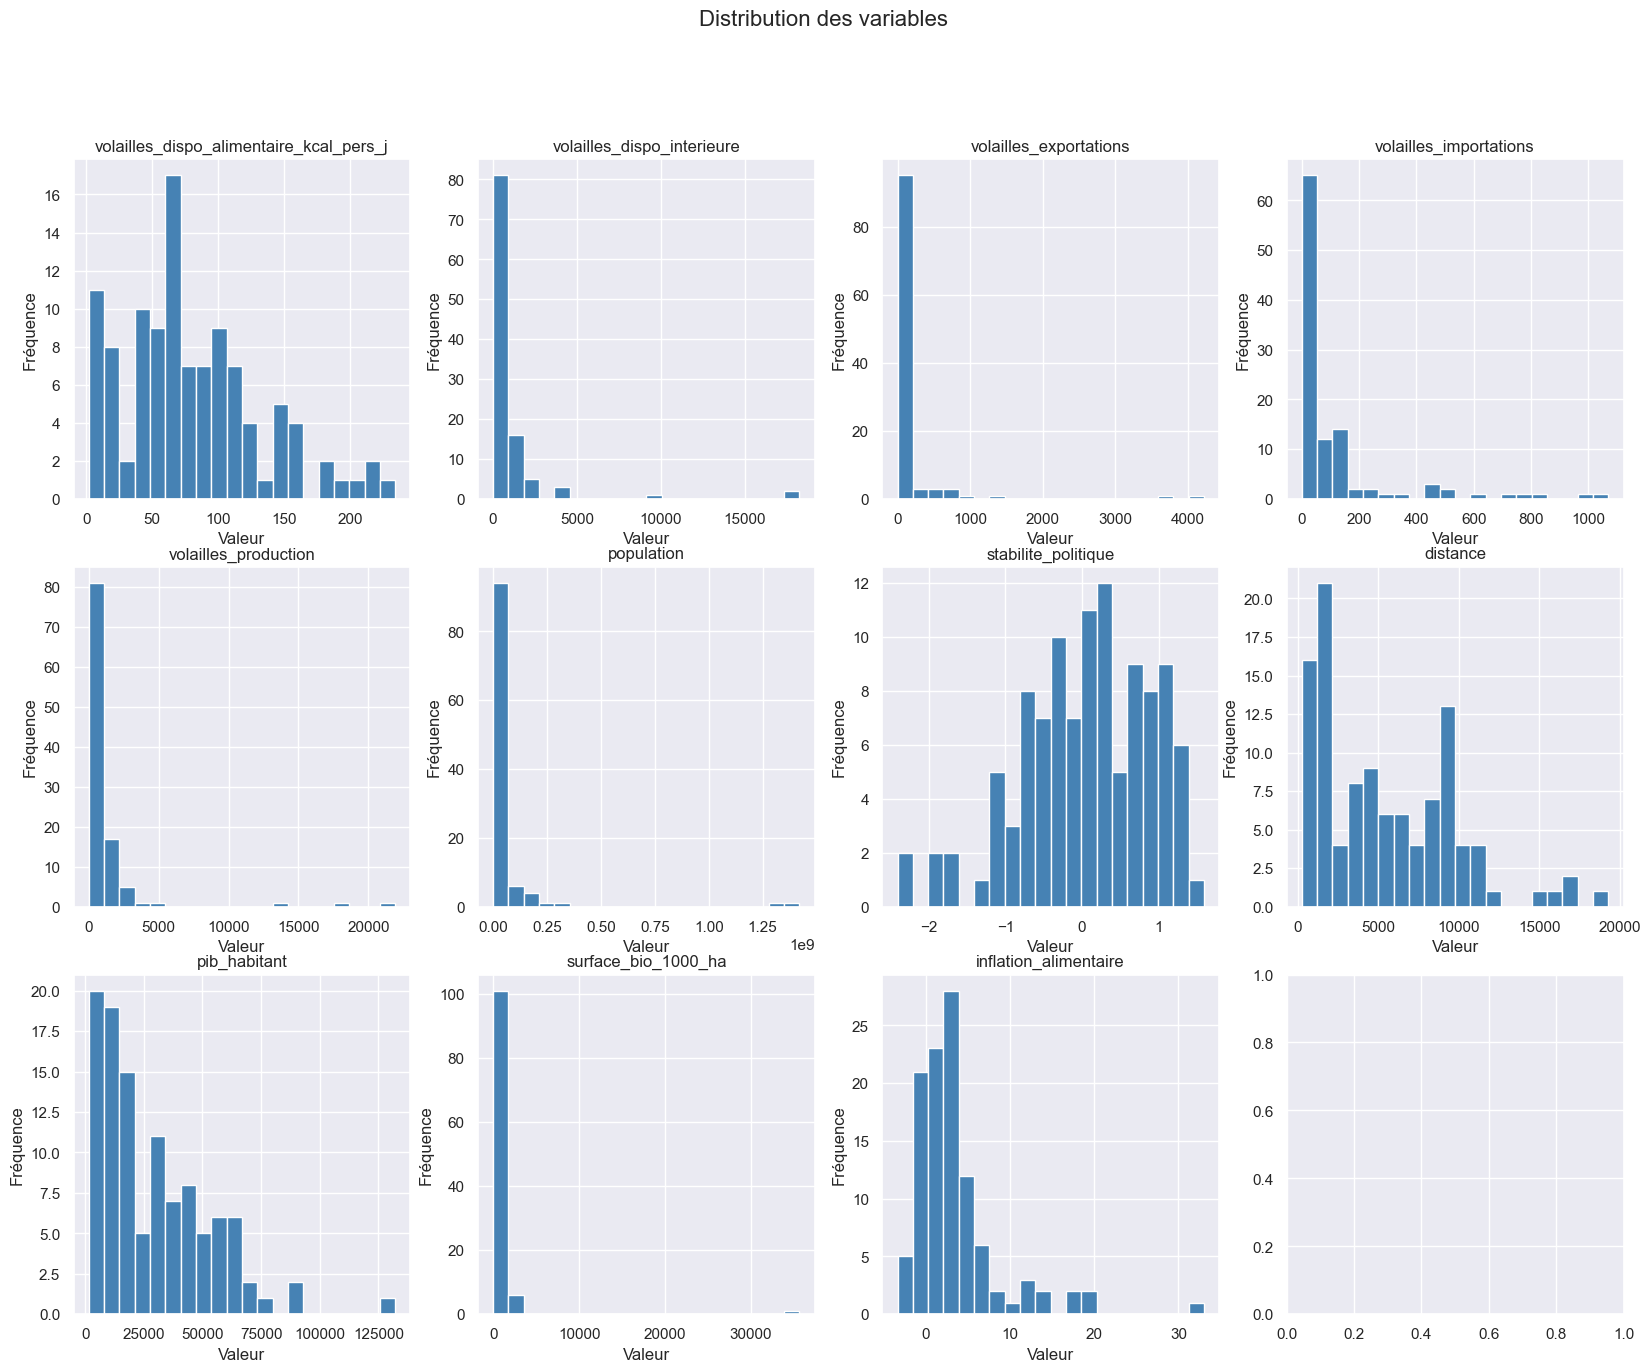

In [519]:
features = [
    'volailles_dispo_alimentaire_kcal_pers_j',
    'volailles_dispo_interieure',
    'volailles_exportations',
    'volailles_importations',
    'volailles_production',
    'population',
    'stabilite_politique',
    'distance',
    'pib_habitant',
    'surface_bio_1000_ha',
    'inflation_alimentaire'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df_analyse[feature], bins=20, color='steelblue')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des variables', fontsize=16)

plt.show()

On peut déjà voir que certaines de ces variables ont une distribution très asymétrique. La disponibilité intérieure, les chiffres de l'exportation, de l'importation et de la production, la population et la surface dédiée à l'agriculture biologique ont des distributions avec de longue queue à droite. 
Les autres distributions sont mieux réparties. La stabilité politique a la distribution qui se rapproche le plus de la normale.

## 5.2 Distribution de nos variables

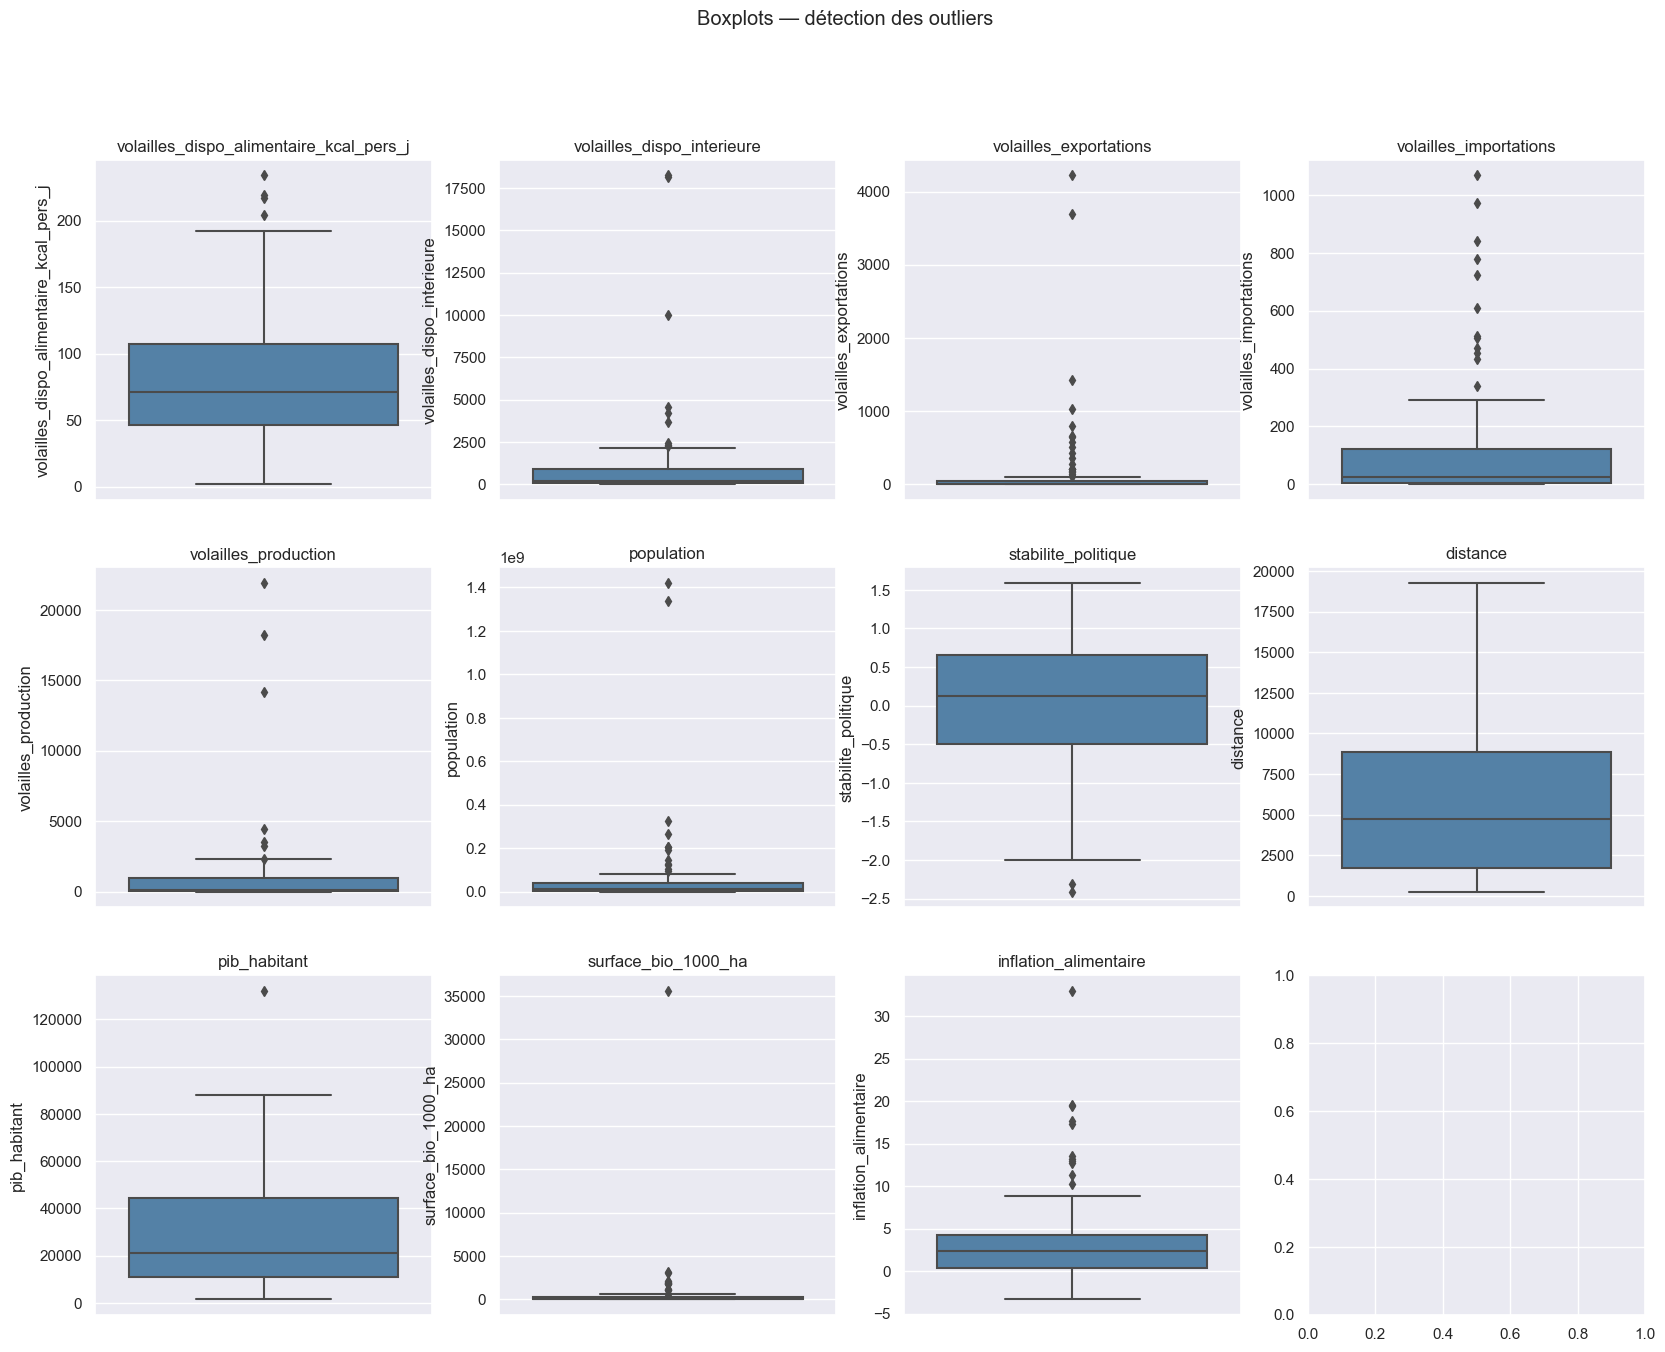

In [527]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

axes = axes.flatten()

for i, feature in enumerate(features):
    
    sns.boxplot(y=df_analyse[feature],  ax=axes[i], color='steelblue')
    
    axes[i].set_title(feature)

plt.suptitle('Boxplots — détection des outliers')

plt.show()

Toutes les variables que nous avons sélectionnées pour notre analyse présentent des outliers (à l'exception de la distance). Certains de ces outliers pourraient même être qualifiés d'extrêmes.
Observons les:
- la disponibilité alimentaire par personne et par jour présente quelques outliers, mais semble autrement assez étalée et homogène.
- la distribution de la disponibilité intérieure est très écrasée. On peut en particulier remarquer un outlier qui écrase les autres points.
- la distribution de l'exportation des volailles est extrêmement écrasée. 2 outliers semblent particulièrement sortir du lot.
- la variable liée à l'importation des volailles présente elle aussi des outliers qui semblent l'écraser vers le bas (bien que dans des proportions moindres que les deux variables précédentes).
- la variable liée à la production de volailles est elle aussi dominée par de très grands outliers.
- la distribution de la population est elle aussi dominée par deux outliers (probablement la Chine et l'Inde)
- la stabilité politique présente quant à elle une boîte plutôt centrée. On peut distinguer deux petits outliers isolés.
- comme nous l'avons dit précédemment, la distance est la seule distribution à ne présenter aucun outliers.
- le pib par habitant est assez bien étalé et semble homogène. On ne distingue qu'un outlier.
- la surface dédiée à l'agriculture biologique est la plus écrasée de toutes les distributions. Un outlier semble complètement dominer tous les autres.
- on peut distinguer plusieurs outliers dans la distribution de l'inflation alimentaire.


### 5.3 Identification des outliers par la méthode interquartile (IQR)

In [578]:
for feature in features_num:
    Q1  = df_analyse[feature].quantile(0.25)
    Q3  = df_analyse[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df_analyse[(df_analyse[feature] < borne_inf) | (df_analyse[feature] > borne_sup)][['pays', feature]]

    if len(outliers) == 0:
        print(f"\nIl y a {len(outliers)} outlier dans la distribution de la variable {feature}.")
    elif len(outliers) == 1:
        print(f"\nIl y a {len(outliers)} outlier dans la distribution de la variable {feature}:")
        print("- ",outliers["pays"].item())
    else:
        print(f"\nIl y a {len(outliers)} outliers dans la distribution de la variable {feature}:")
        for pays in outliers["pays"]:
            print("- ",pays)
    


Il y a 4 outliers dans la distribution de la variable volailles_dispo_alimentaire_kcal_pers_j:
-  Brésil
-  Israël
-  Samoa
-  États-Unis d'Amérique

Il y a 9 outliers dans la distribution de la variable volailles_dispo_interieure:
-  Brésil
-  Chine, continentale
-  Fédération de Russie
-  Inde
-  Indonésie
-  Japon
-  Mexique
-  Royaume-Uni de Grande-Bretagne et d'Irlande du Nord
-  États-Unis d'Amérique

Il y a 20 outliers dans la distribution de la variable volailles_exportations:
-  Allemagne
-  Argentine
-  Belgique
-  Brésil
-  Canada
-  Chili
-  Chine, continentale
-  Danemark
-  Espagne
-  France
-  Fédération de Russie
-  Hongrie
-  Italie
-  Pays-Bas
-  Pologne
-  Royaume-Uni de Grande-Bretagne et d'Irlande du Nord
-  Thaïlande
-  Turquie
-  Ukraine
-  États-Unis d'Amérique

Il y a 12 outliers dans la distribution de la variable volailles_importations:
-  Afrique du Sud
-  Allemagne
-  Arabie saoudite
-  Belgique
-  Chine, continentale
-  France
-  Iraq
-  Japon
-  Mexique


## 5.3 Matrice de corrélation

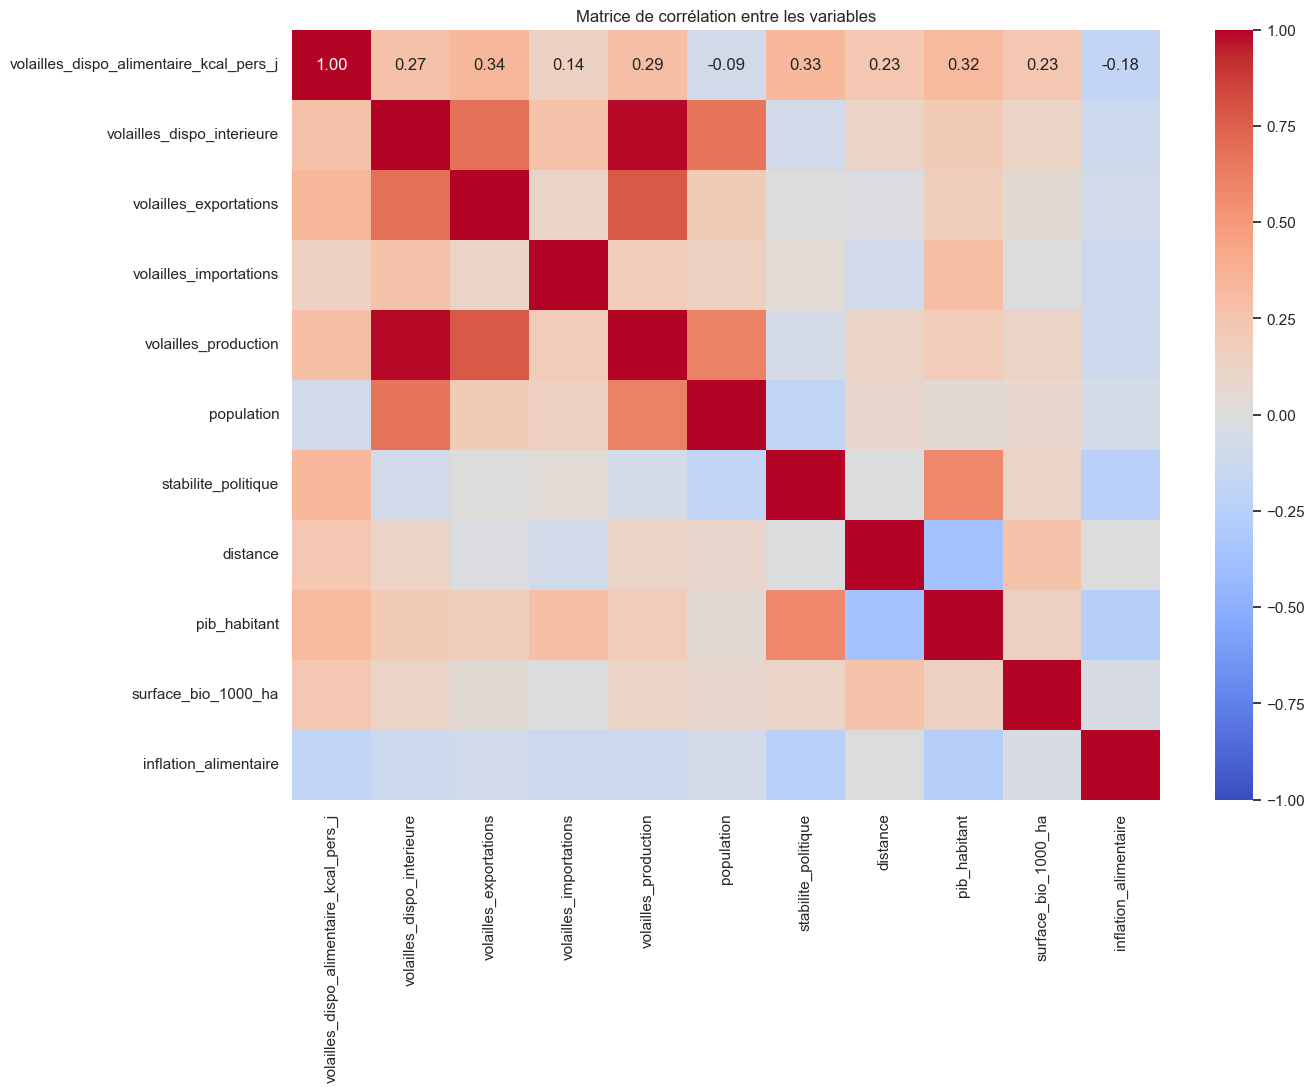

In [581]:
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df_analyse[features_num].corr().round(2)

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            ax=ax)

plt.title('Matrice de corrélation entre les variables')

plt.show()

# 6. Export

In [437]:
df_analyse.to_csv("analyse_final.csv", index=False)